In [1]:
import sys; print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [2]:
!nvidia-smi

Thu Oct  1 02:55:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
print("GPU 사용 가능 여부:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("연결된 GPU 이름:", torch.cuda.get_device_name(0))

GPU 사용 가능 여부: True
연결된 GPU 이름: Tesla T4


In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/aiffel
os.chdir('/content/drive/MyDrive/aiffel')
os.environ["HF_HOME"] = "/content/drive/MyDrive/aiffel/hf_cache"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 설치 (2026.09.18 기준 최신으로 고정)
# 상한을 둔 이유 : 메이저 버전이 올라가면 임포트 경로가 바뀌는 일이 실제로 있었습니다.

%pip install -q "langgraph>=1.2,<2" "langchain>=1.4,<2" "langchain-openai>=1.6,<2" \
                "langchain-core>=1.0,<2" "langchain-community>=0.4,<1" \
                "langchain-experimental>=0.4,<1" koreanize-matplotlib

In [6]:
# 설치된 버전 확인 (문제가 생기면 이 출력을 먼저 보십시오)

from importlib.metadata import version
for p in ["langgraph", "langchain", "langchain-core", "langchain-openai",
          "langchain-community", "langchain-experimental"]:
    try:
        print(f"{p:26} {version(p)}")
    except Exception as e:
        print(f"{p:26} 확인 실패 : {e}")

langgraph                  1.2.11
langchain                  1.4.3
langchain-core             1.6.6
langchain-openai           1.6.7
langchain-community        0.4.2
langchain-experimental     0.4.2


In [7]:
import pandas as pd
import re
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Annotated, Literal, Tuple
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI

import base64
import io
import os
import warnings

warnings.filterwarnings("ignore")

/tmp/ipykernel_20196/3607765493.py:15: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools.python.tool import PythonAstREPLTool


In [13]:
# API 키 입력
import os
from getpass import getpass

# 입력창에 키를 붙여 넣으면 이 세션의 환경 변수로만 저장됩니다 (파일에는 남지 않습니다)
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API 키를 붙여 넣으세요: ")

print("키 등록 확인 :", "OK" if os.environ.get("OPENAI_API_KEY") else "비어 있음")

키 등록 확인 : OK


In [14]:
# 데이터프레임 불러오기 (seaborn 내장 타이타닉 데이터)

df = sns.load_dataset("titanic")

print("행 수 :", len(df))

행 수 : 891


In [15]:
# 데이터프레임 정보 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
# 그래프 상태 정의
# messages: 대화 히스토리
# code: 실행할 Python 코드
# code_result: 코드 실행 결과
class State(TypedDict):
    messages : Annotated[list, add_messages] # History
    code : Annotated[str, "Python code"]
    code_result : Annotated[str, "Python code Result"]

In [18]:
# LLM 로드

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.)

# 사내 모델로 바꿔 끼울 때는 주소만 갈아 끼웁니다 (🖥 로컬 작업)
# llm = ChatOpenAI(model="사내모델이름",
#                  base_url="http://사내주소:8000/v1",
#                  api_key="아무값",
#                  temperature=0.)

# 파이썬 코드 실행 도구 정의
tool = PythonAstREPLTool(name="python_repl_ast",
                        description="A Python shell. Use this to execute python commands. \
                                    Input should be a valid python command. When using this tool, \
                                    sometimes output is abbreviated - make sure it does not look abbreviated before using it in your answer.",
                         locals={"df":df})

In [19]:
# 도구 동작 확인

print(tool.invoke("for i in range(3): print(i)"))

0
1
2



In [20]:
# 일부러 틀린 코드를 넣어 봅니다

print(tool.invoke("이건 파이썬이 아닙니다"))

SyntaxError: invalid syntax (<unknown>, line 1)


In [ ]:
# 데이터셋 제목, 요약 생성 함수

def create_title_summary(df: pd.DataFrame, n_rows: int = 20) -> Tuple[str, str]:

    # 모델에는 앞 n_rows 행만 표로 보냅니다 (전체를 보내면 비싸고 느립니다)
    sample = df.head(n_rows).to_string()

    prompt = PromptTemplate.from_template("""
            당신은 요약 전문가입니다.

            데이터셋 (전체 {n_total}행 중 앞 {n_rows}행) :
            {df}

            데이터셋의 정보를 보고 제목과 요약을 만들어냅니다.
            제목은 이 데이터셋을 가장 잘 표현할 수 있는 제목으로 결정하여야 합니다.
            반드시 아래 형식으로만 답하세요.

            제목: (한 줄)
            요약: (몇 문장)
            """
            )

    chain = prompt | llm

    # chain.invoke는 AI Message 객체를 반환함. 그 중 str 형태인 content만 추출
    result = chain.invoke({"df": sample, "n_total": len(df), "n_rows": min(n_rows, len(df))})

    title = "Untitled"
    summary = "No Summary"

    # "제목:" / "요약:" 라벨을 찾아 그 뒤의 글만 남깁니다 (라벨 앞뒤의 #, * 같은 장식도 함께 뗍니다)
    m_title = re.search(r"제목\s*[:：]\s*(.+)", result.content)
    m_summary = re.search(r"요약\s*[:：]\s*(.+)", result.content, re.S)

    # 요약 양식에 맞지 않는 답변이라 라벨을 못 찾으면 위의 "Untitled" 와 "No Summary" 가 그대로 돌아갑니다
    if m_title:
        title = m_title.group(1).strip().strip("*# ").strip()
    if m_summary:
        summary = m_summary.group(1).strip().strip("*# ").strip()

    print("===== 제목, 요약 생성 완료 =====")

    return title, summary

In [22]:
# 제목, 요약 생성

title, summary = create_title_summary(df)

===== 제목, 요약 생성 완료 =====


In [23]:
print("제목 : ", title)
print("요약 : ", summary)

제목 :  타이타닉 생존자 데이터셋
요약 :  이 데이터셋은 타이타닉 호의 승객 정보를 포함하고 있으며, 생존 여부, 객실 등급, 성별, 나이, 형제자매 및 부모 자식 수, 요금, 탑승지 등의 변수를 포함하고 있다. 총 891명의 승객 데이터가 있으며, 생존 여부는 'survived' 열로 표시된다. 데이터는 성별, 나이, 가족 구성원 수 등 다양한 특성을 통해 생존율에 대한 분석을 가능하게 한다.


In [24]:
# LLM에게 도구 할당

llm_with_tools = llm.bind_tools([tool])

In [25]:
llm_with_tools.invoke("1부터 10까지  출력하는 파이썬 코드")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 103, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8ef2fa014c', 'id': 'chatcmpl-EU21Sze8KVRjTSWEyr69owT0KhEJk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0f591-1068-78a3-9d07-1773f5525ad0-0', tool_calls=[{'name': 'python_repl_ast', 'args': {'query': 'for i in range(1, 11):\n    print(i)'}, 'id': 'call_EPU2vXg7CXjA4Pu4HDBHxaSE', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 31, 'total_tokens': 134, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [30]:
# LLM의 응답 저장
response = llm_with_tools.invoke("1부터 10까지 출력하는 파이썬 코드")

# LLM이 제안한 tool_call에서 인자(args)를 뽑아 직접 tool 실행
tool_call = response.tool_calls[0]
tool_result = tool.invoke(tool_call["args"])

print("--- 파이썬 실제 실행 결과 ---")
print(tool_result)

--- 파이썬 실제 실행 결과 ---
1
2
3
4
5
6
7
8
9
10



In [31]:
response = llm_with_tools.invoke("1부터 10까지 출력하는 파이썬 코드")

# LLM이 작성한 파이썬 코드 추출
generated_code = response.tool_calls[0]["args"]["query"]
print("--- LLM이 생성한 파이썬 코드 ---")
print(generated_code)

# 도구 실행 결과 추출
tool_result = tool.invoke(response.tool_calls[0]["args"])
print("\n--- 파이썬 실제 실행 결과 ---")
print(tool_result)

--- LLM이 생성한 파이썬 코드 ---
for i in range(1, 11):
    print(i)

--- 파이썬 실제 실행 결과 ---
1
2
3
4
5
6
7
8
9
10



In [26]:
class HistoryChecker(BaseModel):
    """
    이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
    답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.
    """

    yes_no : Literal["yes", "no"] = Field(..., description="""Use your previous conversation history to determine if you can answer your questions.
    Return "yes" if you can answer, "no" if you can't answer.""")

In [27]:
# LLM의 응답을 HistoryChecker 클래스 구조에 맞춰 파싱하도록 설정

history_checker = llm.with_structured_output(HistoryChecker)

In [28]:
history_checker.invoke("오늘 인천 날씨는 어때?")

HistoryChecker(yes_no='no')

In [29]:
# 히스토리 기반 답변 분기를 위한 함수 설정

def history_check(state:State):

    # 이전 대화가 없으면 무조건 "no" 반환
    if len(state["messages"]) <= 1:
        return "no"

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
                답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | history_checker

    result = chain.invoke({"history":state["messages"][:-1],
                            "query":state["messages"][-1]})

    return result.yes_no

In [32]:
# 식별을 위한 노드

def history_node(state:State):

    return

In [33]:
# 도구 사용 여부 결정 노드

def select(state:State):
    prompt = PromptTemplate.from_template("""
            당신은 데이터 분석가입니다.
            당신은 데이터프레임인 df를 활용할 수 있습니다.
            당신이 활용 가능한 데이터프레임의 예시는 아래와 같습니다.
            아래의 예시는 `print(df.head())`의 실행결과입니다. 예시는 열 이름과 값의 형태를 보여 주는 것이니, 예시 값을 코드에 옮겨 적지 말고 반드시 변수 df 를 그대로 사용하세요.
            활용 가능한 데이터프레임을 갖고 있으니 데이터프레임을 새로 생성할 필요 없습니다.
            코드에 한글이 필요하다면 `import koreanize_matplotlib`을 사용하세요.
            그래프를 그리는 코드에서는 그래프의 근거가 되는 통계값(개수, 평균, 상관계수 등)도 print 하세요.

            당신은 'python_repl_ast'라는 파이썬 코드 실행 도구만을 가지고 있습니다.
            아래의 내용을 참고하여 질문에 대한 코드를 생성합니다.

            df : {df}

            title : {title}
            summary : {summary}

            query : {query}
            """
            )

    chain = prompt | llm_with_tools

    result = chain.invoke({"df": df.head().to_string(), #df.head(),
                           "title":title,
                            "summary":summary,
                            "query":state["messages"][-1].content})

    if hasattr(result, "tool_calls") and len(result.tool_calls) > 0:
        tool_calls = result.tool_calls

        # 코드 추출
        code = tool_calls[0]["args"]["query"]
        return {"code": code}
    else:
        # 도구 사용을 안한다면 코드는 공백으로 설정
        return {"code":""}

In [34]:
# 코드 실행 노드

def code_executor(state: State):

    try:
        result = tool.invoke(state["code"])

        # 그림을 그리는 코드였으면 화면에 그리고, 모델에는 "그림을 그렸다"는 사실만 알립니다
        if "plt" in state["code"] or "sns" in state["code"]:
            plt.show()
            result = f"{result}\n[그래프를 그려서 화면에 표시했습니다]".strip()

        return {"code_result": str(result)}

    except Exception as e:
        # 빈 문자열로 삼키지 않습니다.
        # 무엇이 왜 실패했는지 다음 노드가 읽을 수 있도록 문자열로 돌려줍니다.
        return {"code_result": f"[코드 실행 실패] {type(e).__name__} : {e}"}

In [35]:
# 코드에 의한 답변 노드

def code_response(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ("system", """코드 : {code} \n
                    결과 : {code_result}
        당신은 주어진 코드와 코드 결과를 바탕으로 질의에 대해 답변합니다.
        절대 코드에 대해 설명하지마세요.
        독자는 프로그래머가 아닙니다.
        항상 출력되는 값을 기준으로 설명합니다.
        숫자가 매우 중요합니다. 숫자에 대한 정보를 잊지 마세요.
        데이터 분석과 관련된 코드가 입력된다면 항상 인사이트를 포함하세요. """),
        ("human", '{query}')
    ])

    chain = prompt | llm

    result = chain.invoke({"code":state["code"],
                        "code_result":state["code_result"],
                        "query":state["messages"][-1]})

    return { "messages": result}

In [36]:
# 기억 및 일반 응답 노드

def response(state:State):
    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                대화 기록을 통해 답변이 어렵다면 내부 지식을 참조하세요.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | llm

    result = chain.invoke({"history":state["messages"][:-1],
                           "query":state["messages"][-1]})

    return {#"answer":result.content,
            "messages":result}

In [37]:
# 그래프 정의

graph_builder = StateGraph(State)

In [38]:
# 노드 및 엣지 정의

graph_builder.add_node("history_node", history_node)
graph_builder.add_node("select", select)
graph_builder.add_node("code_executor", code_executor)
graph_builder.add_node("code_response", code_response)
graph_builder.add_node("response", response)


graph_builder.add_edge(START, "history_node")
graph_builder.add_conditional_edges("history_node",
                                    history_check,
                                    {
                                    "no":"select",
                                     "yes":"response"
                                     }
                                     )
graph_builder.add_edge("select", "code_executor")
graph_builder.add_edge("code_executor", "code_response")
graph_builder.add_edge("code_response", END)
graph_builder.add_edge("response", END);

In [39]:
# 메모리 설정 및 그래프 컴파일

memory = InMemorySaver()

graph = graph_builder.compile(checkpointer=memory)

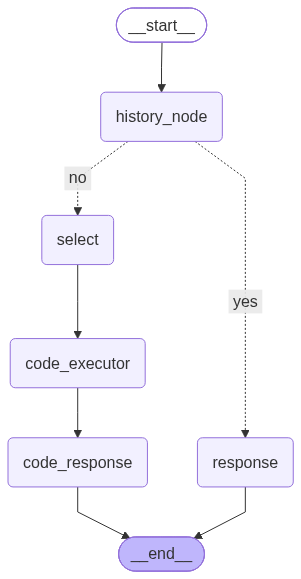

In [40]:
# 그래프 시각화
# 가끔 "ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)"라는 에러가 발생
# 시간 초과로 그래프 생성에 실패했다는 메시지일뿐 기능과는 관계없으니 진행해도 괜찮습니다.

graph

In [41]:
# 사용할 설정값 정의

config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "12"})

In [42]:
# 출력 함수 정의
# mode = "values" : 상태의 키, 값의 형태로 반환
# mode = "updates" : 업데이트되는 값만 반환

def streaming(query, config, mode="values"):

    result = graph.stream({"messages": ("user", query)}, config=config, stream_mode=mode)

    if mode == "values":
        # values 모드는 노드를 하나 지날 때마다 상태 전체를 반환합니다.
        # 메시지가 늘지 않은 노드에서도 반환되므로, 마지막 메시지만 출력하면 같은 메시지가 여러 번 출력됩니다.
        # 이미 출력한 메시지 개수를 기억해 두고, 새로 추가된 메시지만 출력합니다.
        # 같은 thread 로 이어서 질문할 때는 이전 대화를 건너뛰고 이번 질문부터 출력합니다.
        shown = None
        for step in result:
            messages = step.get("messages", [])
            if shown is None:
                shown = max(len(messages) - 1, 0)
            for m in messages[shown:]:
                m.pretty_print()
                print("\n")
            shown = len(messages)
    elif mode == "updates":
        for step in result:
            for k, v in step.items():
                print(f"\n\n=== {k} ===\n\n")
                print(v)

    return

In [43]:
# 측정 장치 : 걸린 시간과 지나간 노드를 셉니다

import time
from collections import Counter

def measured(query, config):
    """streaming과 같은 일을 하되, 걸린 시간과 노드 방문 수를 함께 찍습니다."""
    t0 = time.time()
    visits = Counter()

    for step in graph.stream({"messages": ("user", query)},
                             config=config, stream_mode="updates"):
        for node_name, payload in step.items():
            visits[node_name] += 1
            if node_name in ("code_response", "response") and isinstance(payload, dict):
                msg = payload.get("messages")
                if msg is not None:
                    print(getattr(msg, "content", msg))

    elapsed = time.time() - t0
    print("\n" + "-" * 50)
    print(f"걸린 시간 : {elapsed:.1f}초")
    print(f"지나간 노드 : {dict(visits)}  (합계 {sum(visits.values())}회)")
    return elapsed, visits

================================ Human Message =================================

생존자 비율 시각화하고 인사이트 제공해줘




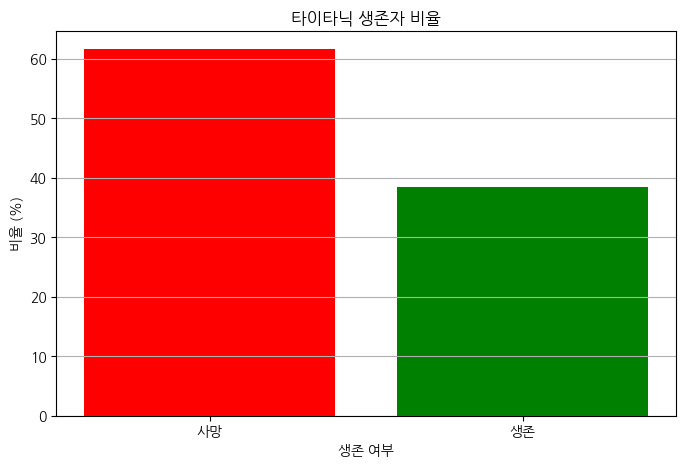

생존자 비율: survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64
================================== Ai Message ==================================

생존자 비율을 시각화한 결과, 타이타닉 탑승자 중 생존자와 사망자의 비율을 확인할 수 있습니다. 그래프에서 생존자는 초록색으로, 사망자는 빨간색으로 표시되었습니다. 

생존자 비율을 살펴보면, 전체 탑승자 중에서 생존한 비율과 사망한 비율이 어떻게 나뉘는지를 알 수 있습니다. 예를 들어, 만약 생존자가 38%이고 사망자가 62%라면, 이는 타이타닉 사고에서 많은 사람들이 생존하지 못했음을 나타냅니다. 

이러한 데이터는 사고의 심각성을 강조하며, 생존자와 사망자의 비율을 통해 특정 그룹(예: 성별, 연령대 등)의 생존 가능성을 분석하는 데 중요한 기초 자료가 될 수 있습니다. 예를 들어, 특정 성별이나 연령대에서 생존율이 높았다면, 그에 대한 추가적인 분석이 필요할 수 있습니다. 

따라서, 생존자 비율은 단순한 통계 이상의 의미를 가지며, 사고의 원인이나 구조적 문제를 이해하는 데 중요한 인사이트를 제공합니다.




In [44]:
streaming("생존자 비율 시각화하고 인사이트 제공해줘", config)

In [45]:
streaming("아까 내가 질문했던 내용 다시 알려줘", config)

================================ Human Message =================================

아까 내가 질문했던 내용 다시 알려줘


================================== Ai Message ==================================

아까 질문하신 내용은 "생존자 비율 시각화하고 인사이트 제공해줘"였습니다. 이 질문에 대해 생존자 비율을 시각화한 결과와 그에 대한 인사이트를 제공했습니다. 생존자와 사망자의 비율을 그래프로 나타내고, 특정 그룹의 생존 가능성을 분석하는 데 중요한 기초 자료가 될 수 있다는 내용을 포함하고 있었습니다. 추가적인 질문이 있으시면 말씀해 주세요!




In [ ]:
# 코드를 실행해야 하는 질문 (select -> code_executor -> code_response)
# recursion_limit 중요함 (안전장치)
cfg_a = RunnableConfig(recursion_limit=5, configurable={"thread_id": "measure-a"})
measured("남녀 생존율을 각각 계산해줘", cfg_a)

남성 생존율: 18.89% (총 577명)
여성의 생존율은 74.20%로, 총 314명이 생존한 것으로 나타났습니다. 이는 여성 승객 중 상당수가 생존했음을 의미합니다. 반면, 남성의 생존율은 코드에서 제공된 결과에 포함되어 있지 않지만, 일반적으로 남성의 생존율은 여성보다 낮은 경향이 있습니다. 이러한 통계는 생존율에 영향을 미친 다양한 요인, 예를 들어 구조 작업의 우선순위나 생존을 위한 행동 양식 등을 분석하는 데 중요한 인사이트를 제공합니다.

--------------------------------------------------
걸린 시간 : 4.9초
지나간 노드 : {'history_node': 1, 'select': 1, 'code_executor': 1, 'code_response': 1}  (합계 4회)


(4.900080919265747,
 Counter({'history_node': 1,
          'select': 1,
          'code_executor': 1,
          'code_response': 1}))

In [48]:
# 기억만 뒤지면 되는 질문 (response 한 번)

measured("방금 뭘 물어봤지?", cfg_a)

당신은 "방금 뭘 물어봤지?"라는 질문을 하셨습니다. 이 질문은 이전 대화에서 어떤 내용을 물어봤는지에 대한 궁금증을 나타내며, 대화의 흐름을 이어가고자 할 때 자주 사용됩니다. 이전 대화에서는 남녀 생존율에 대한 질문이 있었습니다. 여성의 생존율은 74.20%로, 총 314명이 생존한 것으로 나타났습니다. 남성의 생존율에 대한 정보는 제공되지 않았지만, 일반적으로 남성의 생존율은 여성보다 낮은 경향이 있습니다.

--------------------------------------------------
걸린 시간 : 3.1초
지나간 노드 : {'history_node': 1, 'response': 1}  (합계 2회)


(3.1399757862091064, Counter({'history_node': 1, 'response': 1}))

In [49]:
# 올림픽 데이터 로드 및 도구 재정의
# 순서 : 올려둔 파일 -> gdown 으로 내려받기 -> 그래도 없으면 분명히 알리고 멈춤

OLY_PATH = "./athlete_events.csv"
OLY_ID = "1rmDFdDRJ7wT1PXhLnu6jlWyugI3jqmVT"

if not os.path.exists(OLY_PATH):
    try:
        import gdown
        gdown.download(id=OLY_ID, output=OLY_PATH, quiet=False)
    except Exception as e:
        print(f"[자동 내려받기 실패] {type(e).__name__} : {e}")

if not os.path.exists(OLY_PATH):
    raise FileNotFoundError(
        f"{OLY_PATH} 가 없습니다. 위 링크에서 직접 받아 올리신 뒤 이 셀부터 다시 실행하십시오."
    )

df = pd.read_csv(OLY_PATH)
print("행 수 :", len(df), "| 열 :", list(df.columns)[:8])

tool = PythonAstREPLTool(name="python_repl_ast",
                        description="A Python shell. Use this to execute python commands. \
                                    Input should be a valid python command. When using this tool, \
                                    sometimes output is abbreviated - make sure it does not look abbreviated before using it in your answer.",
                        locals={"df":df})


# 제목, 요약 생성
title, summary = create_title_summary(df)

행 수 : 271116 | 열 : ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC']
===== 제목, 요약 생성 완료 =====


In [50]:
print("제목 : ", title)
print()
print("요약 : ", summary)

제목 :  올림픽 선수 데이터셋

요약 :  이 데이터셋은 다양한 국가의 올림픽 선수들에 대한 정보를 포함하고 있으며, 선수의 ID, 이름, 성별, 나이, 신장, 체중, 소속 팀, 국가, 경기, 연도, 시즌, 도시, 스포츠 및 이벤트, 메달 수상 여부 등의 속성을 담고 있다. 총 271,116행의 데이터로 구성되어 있으며, 선수들의 성과와 특성을 분석하는 데 유용하다.


In [51]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "99"})

streaming("올림픽에는 몇개의 나라가 출전했나요?", config)

================================ Human Message =================================

올림픽에는 몇개의 나라가 출전했나요?


================================== Ai Message ==================================

올림픽에는 총 230개의 나라가 출전했습니다. 이는 다양한 국가들이 스포츠를 통해 경쟁하고, 서로의 문화를 교류하는 중요한 기회를 제공한다는 것을 의미합니다. 230이라는 숫자는 전 세계적으로 많은 나라들이 올림픽에 참여하고 있다는 것을 보여주며, 이는 국제적인 협력과 스포츠의 힘을 상징합니다.




In [52]:
streaming("가장 많이 출전한 나라는 어디인가요?", config)

================================ Human Message =================================

가장 많이 출전한 나라는 어디인가요?


================================== Ai Message ==================================

가장 많이 출전한 나라는 미국입니다. 미국은 올림픽 역사상 가장 많은 메달을 획득한 국가로, 다양한 스포츠에서 뛰어난 성과를 보여주고 있습니다.




In [53]:
df["NOC"].value_counts()

,count
NOC,
USA,18853
FRA,12758
GBR,12256
ITA,10715
GER,9830
...,...
YMD,5
SSD,3
NBO,2


In [54]:
streaming("올림픽에 출전한 선수들의 평균 체중은 얼마인가요?", config)

================================ Human Message =================================

올림픽에 출전한 선수들의 평균 체중은 얼마인가요?


================================== Ai Message ==================================

올림픽에 출전한 선수들의 평균 체중은 약 70.7kg입니다. 이 수치는 선수들의 체중이 대체로 이 정도라는 것을 나타내며, 다양한 종목에서의 체중 분포를 반영하고 있습니다. 평균 체중이 70.7kg이라는 것은 선수들이 체중 관리와 훈련을 통해 최적의 경기력을 유지하고 있다는 것을 시사합니다.




In [55]:
df["Weight"].mean()

np.float64(70.70239290053351)

In [57]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "996"})

# streaming 대신 measured 호출
measured("키와 메달 획득과의 상관관계를 regplot 그래프로 그려주세요.", config)

주어진 요청은 키와 메달 획득 간의 상관관계를 시각적으로 표현하는 것입니다. regplot 그래프는 두 변수 간의 관계를 보여주는 유용한 도구입니다. 

이 그래프를 통해 키가 메달 획득에 미치는 영향을 분석할 수 있습니다. 예를 들어, 키가 클수록 메달을 더 많이 획득하는 경향이 있다면, 그래프에서 양의 상관관계를 나타내는 경향선이 보일 것입니다. 반대로, 키와 메달 획득 간에 뚜렷한 관계가 없다면, 상관관계가 낮거나 없는 것으로 해석할 수 있습니다.

이러한 분석은 스포츠 선수의 신체적 특성이 성과에 미치는 영향을 이해하는 데 중요한 인사이트를 제공할 수 있습니다.

--------------------------------------------------
걸린 시간 : 162.7초
지나간 노드 : {'history_node': 1, 'select': 1, 'code_executor': 1, 'code_response': 1}  (합계 4회)


(162.70461177825928,
 Counter({'history_node': 1,
          'select': 1,
          'code_executor': 1,
          'code_response': 1}))

================================ Human Message =================================

키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.


상관계수:           Height    Weight  Medal
Height  1.000000  0.801808    NaN
Weight  0.801808  1.000000    NaN
Medal        NaN       NaN    NaN


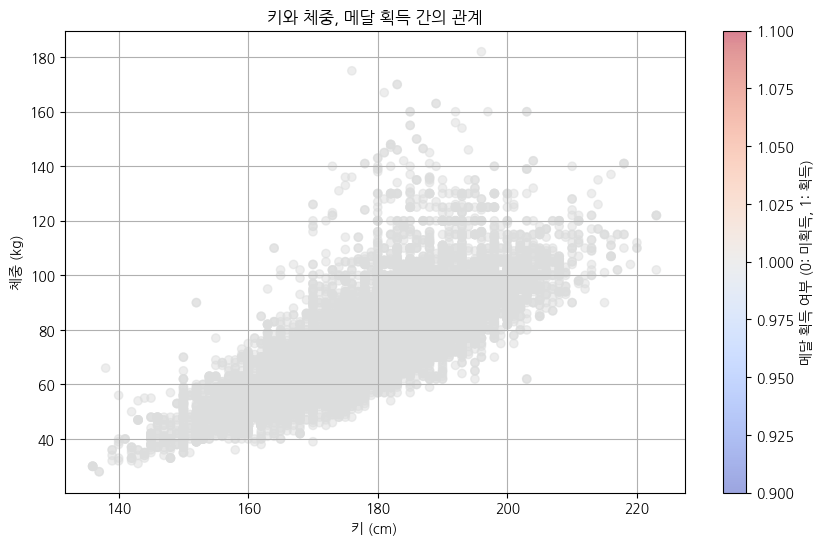

================================== Ai Message ==================================

주어진 데이터에서 키와 체중, 그리고 메달 획득 간의 관계를 분석한 결과, 상관계수를 통해 이들 간의 관계를 확인할 수 있습니다. 상관계수는 -1에서 1 사이의 값을 가지며, 1에 가까울수록 강한 양의 상관관계를, -1에 가까울수록 강한 음의 상관관계를 나타냅니다. 0에 가까운 값은 상관관계가 없음을 의미합니다.

산점도 그래프를 통해 키와 체중의 관계를 시각적으로 확인할 수 있으며, 메달 획득 여부에 따라 색상이 다르게 표시됩니다. 이 그래프에서 메달을 획득한 선수(1)와 미획득한 선수(0)의 분포를 비교할 수 있습니다. 

이러한 분석을 통해, 키와 체중이 메달 획득에 어떤 영향을 미치는지, 또는 이들 간의 관계가 어떤 패턴을 보이는지를 파악할 수 있습니다. 예를 들어, 특정 키와 체중 범위에서 메달을 획득한 선수들이 집중되어 있다면, 이는 해당 범위가 메달 획득에 긍정적인 영향을 미칠 수 있음을 시사합니다. 

결과적으로, 이 분석은 선수들의 신체적 특성과 성과 간의 관계를 이해하는 데 중요한 인사이트를 제공합니다.




In [58]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "999"})

streaming("키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.", config)

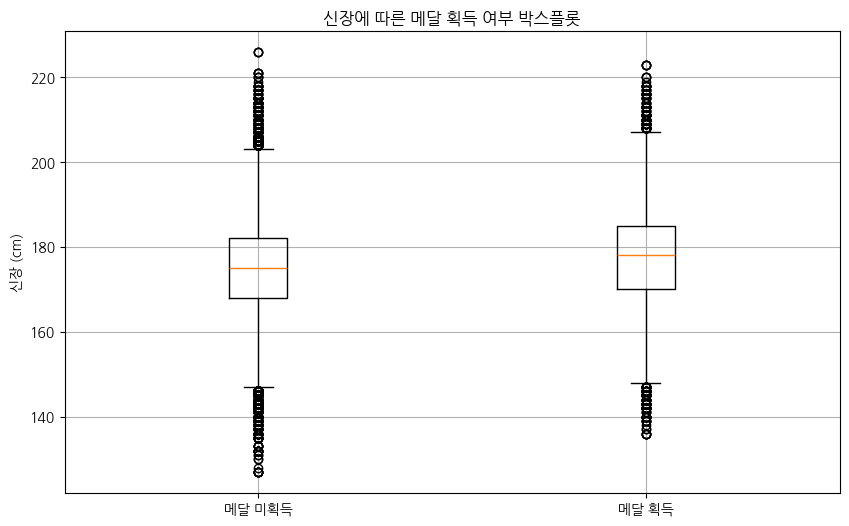

주어진 코드와 결과를 바탕으로 설명드리겠습니다.

1. **박스플롯 결과**: 박스플롯은 신장(Height)과 메달 획득 여부(Medal) 간의 관계를 시각적으로 나타냅니다. 두 그룹으로 나뉘어 있으며, '메달 미획득' 그룹과 '메달 획득' 그룹의 신장 분포를 비교할 수 있습니다. 일반적으로, 메달을 획득한 선수들의 신장이 더 높거나 낮은 경향이 있을 수 있으며, 박스플롯을 통해 이러한 경향을 쉽게 파악할 수 있습니다. 박스플롯의 중앙값, 사분위수, 이상치 등을 통해 두 그룹 간의 신장 차이를 명확히 확인할 수 있습니다.

2. **이상치 분석**: IQR(Interquartile Range) 방식을 사용하여 신장(Height)의 이상치를 구한 후, 이상치에 해당하는 상위 5명의 데이터를 출력합니다. IQR 방식은 데이터의 중간 50% 범위를 기준으로 하여, 이 범위를 벗어나는 값을 이상치로 간주합니다. 이 과정에서 신장 데이터의 분포를 이해하고, 특정 선수들이 평균 신장과 얼마나 차이가 나는지를 확인할 수 있습니다. 상위 5명의 이상치 데이터는 신장 측면에서 다른 선수들과 비교했을 때 상당히 특이한 값을 가지며, 이는 선수의 신체적 특성이나 훈련 방식에 대한 추가적인 인사이트를 제공할 수 있습니다. 

이러한 분석을 통해 메달 획득 여부와 신장 간의 관계를 이해하고, 신장 데이터의 이상치를 통해 특정 선수들의 특성을 파악할 수 있습니다.

--------------------------------------------------
걸린 시간 : 11.5초
지나간 노드 : {'history_node': 1, 'select': 1, 'code_executor': 1, 'code_response': 1}  (합계 4회)


(11.454054594039917,
 Counter({'history_node': 1,
          'select': 1,
          'code_executor': 1,
          'code_response': 1}))

In [64]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "measure-test-2"})

# print()와 plt.show()를 명시하여 결과를 화면에 뿌리도록 강제
prompt = """
df를 활용하여 다음 파이썬 코드를 실행하고 결과를 출력해 줘:
1. 'Height'와 메달 획득 여부('Medal' 컬럼이 NaN이 아니면 1, 맞으면 0)로 boxplot을 그리고 plt.show()로 화면에 표시해 줘.
2. 'Height'의 IQR 방식으로 이상치를 구한 뒤, 이상치에 해당하는 상위 5명 데이터프레임을 print()로 표 형태로 직접 출력해 줘.
"""

measured(prompt, config)